# Triangle-based Jacobian criterion

Alternative to the central-difference Jacobian determinant constraint: split every grid cell into triangles along **both** diagonals (4 triangles per cell) and require every triangle's signed area to exceed the feasibility threshold.

- **Detection is exact, not approximate.** Each signed triangle area is the exact Jacobian determinant of the piecewise-linear map on that triangle.
- **Strict injectivity guarantee.** If all 4 triangles per cell are positive everywhere, the PL warp is provably bijective under either diagonal triangulation.
- **Stronger than shoelace.** A cell can have positive shoelace area while one of its triangles is flipped (non-convex deformed quad). Requiring all 4 triangles catches this.

The solver below drops the CD-Jdet constraint entirely and optimises against the triangle-strict criterion instead.

In [1]:
import os, sys, time
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
from matplotlib.colors import TwoSlopeNorm
from matplotlib.cm import ScalarMappable, get_cmap
from scipy.optimize import minimize, NonlinearConstraint

from dvfopt import jacobian_det2D, iterative_serial
from test_cases import make_deformation, SYNTHETIC_CASES

## Test case

Use `03d_20x20_crossing` from the benchmark suite — a 20×20 crossing deformation that produces strong folding, same case exercised by `benchmark-constraint-modes.ipynb`.

In [2]:
CASE_KEY = "03d_20x20_crossing"
deformation, ms, fs = make_deformation(CASE_KEY)
phi_init = np.stack([deformation[1, 0], deformation[2, 0]])  # [dy, dx]

H, W = phi_init.shape[-2:]
jac_init = np.squeeze(jacobian_det2D(phi_init))
print(f"Case: {SYNTHETIC_CASES[CASE_KEY]['title']}")
print(f"Grid: {H}x{W}")
print(f"Initial CD-Jdet:  negative pixels = {(jac_init <= 0).sum()}, "
      f"min = {jac_init.min():+.4f}")

Building data for Laplacian Sparse Matrix A (optimized)
Creating Laplacian Sparse Matrix A
Case: Case 3d — 20×20 crossing points
Grid: 20x20
Initial CD-Jdet:  negative pixels = 30, min = -1.0252


## Triangle fold detection

Each grid cell has 4 corners — TL, TR, BR, BL — and 2 possible diagonal splits:

- **Diagonal "\\\\" (TL↔BR):**  T1 = (TL, TR, BR)   T2 = (TL, BR, BL)
- **Diagonal "/" (TR↔BL):**     T3 = (TL, TR, BL)   T4 = (TR, BR, BL)

Signed area of each triangle = ½ · z-component of the triangle's cross product. This **is** the Jacobian determinant of the PL interpolant on that triangle — not an approximation.

A cell is **strict-safe** iff all 4 triangle areas are positive. A single flipped triangle in either diagonal split implies the PL map fails injectivity under that triangulation, which catches the non-convex-deformed-quad case the shoelace constraint misses.

In [3]:
def all_triangle_areas(phi):
    """Signed areas of all 4 triangles per cell, both diagonal splits.

    Parameters
    ----------
    phi : ndarray, shape ``(2, H, W)`` with channels [dy, dx]

    Returns
    -------
    areas : ndarray, shape ``(4, H-1, W-1)``
        Channels:
          0 : T1 = (TL, TR, BR)     diagonal TL-BR
          1 : T2 = (TL, BR, BL)     diagonal TL-BR
          2 : T3 = (TL, TR, BL)     diagonal TR-BL
          3 : T4 = (TR, BR, BL)     diagonal TR-BL
    """
    H, W = phi.shape[-2:]
    dy, dx = phi[0], phi[1]
    ref_y, ref_x = np.mgrid[:H, :W]
    X = ref_x + dx
    Y = ref_y + dy

    x0, y0 = X[:-1, :-1], Y[:-1, :-1]  # TL
    x1, y1 = X[:-1, 1:],  Y[:-1, 1:]   # TR
    x2, y2 = X[1:, 1:],   Y[1:, 1:]    # BR
    x3, y3 = X[1:, :-1],  Y[1:, :-1]   # BL

    T1 = 0.5 * ((x1 - x0) * (y2 - y0) - (x2 - x0) * (y1 - y0))  # TL,TR,BR
    T2 = 0.5 * ((x2 - x0) * (y3 - y0) - (x3 - x0) * (y2 - y0))  # TL,BR,BL
    T3 = 0.5 * ((x1 - x0) * (y3 - y0) - (x3 - x0) * (y1 - y0))  # TL,TR,BL
    T4 = 0.5 * ((x2 - x1) * (y3 - y1) - (x3 - x1) * (y2 - y1))  # TR,BR,BL
    return np.stack([T1, T2, T3, T4])


def triangle_fold_stats(phi, threshold=0.0):
    """Count triangles and cells flagged by the strict triangle criterion.

    Returns a dict with per-diagonal flipped-triangle counts, total flipped
    triangles, number of cells with at least one flipped triangle, and the
    minimum triangle area across the whole grid.
    """
    A = all_triangle_areas(phi)
    flipped = A <= threshold
    cells_flipped = flipped.any(axis=0)  # (H-1, W-1)
    return {
        "n_flipped_T1": int(flipped[0].sum()),
        "n_flipped_T2": int(flipped[1].sum()),
        "n_flipped_T3": int(flipped[2].sum()),
        "n_flipped_T4": int(flipped[3].sum()),
        "n_flipped_total": int(flipped.sum()),
        "n_cells_flipped": int(cells_flipped.sum()),
        "min_tri_area": float(A.min()),
    }

In [4]:
# Sanity: identity map → all triangles have area 0.5 (unit cell, split into halves)
_phi_id = np.zeros((2, 5, 5))
_id_areas = all_triangle_areas(_phi_id)
assert np.allclose(_id_areas, 0.5), "identity check failed"
print(f"Sanity: identity map triangle areas all = {_id_areas.mean():.4f}  (expect 0.5)")

# Report stats on the initial deformation
stats_init = triangle_fold_stats(phi_init, threshold=0.0)
print(f"\nInitial field — triangle fold stats:")
for k, v in stats_init.items():
    print(f"  {k:<20s} {v}")

n_cells = (H - 1) * (W - 1)
print(f"\n  cells flipped : {stats_init['n_cells_flipped']} / {n_cells}")
print(f"  CD-Jdet neg   : {(jac_init <= 0).sum()} pixels (for comparison)")

Sanity: identity map triangle areas all = 0.5000  (expect 0.5)

Initial field — triangle fold stats:
  n_flipped_T1         36
  n_flipped_T2         36
  n_flipped_T3         36
  n_flipped_T4         36
  n_flipped_total      144
  n_cells_flipped      72
  min_tri_area         -0.7430733182591741

  cells flipped : 72 / 361
  CD-Jdet neg   : 30 pixels (for comparison)


## Visualisation

Draws the deformed grid wireframe and overlays the 4 triangles per cell (one panel per diagonal split). Each triangle is filled with its signed-area value via a diverging colormap; **flipped (negative-area) triangles get a bold red outline.** This makes it easy to see exactly which triangulations lose injectivity and where.

In [5]:
def _deformed_vertices(phi):
    H, W = phi.shape[-2:]
    ref_y, ref_x = np.mgrid[:H, :W]
    return ref_x + phi[1], ref_y + phi[0]


def _draw_wireframe(ax, phi, lw=0.4, color="k"):
    H, W = phi.shape[-2:]
    X, Y = _deformed_vertices(phi)
    for i in range(H):
        ax.plot(X[i, :], Y[i, :], color=color, linewidth=lw, zorder=3)
    for j in range(W):
        ax.plot(X[:, j], Y[:, j], color=color, linewidth=lw, zorder=3)


def plot_grid_with_triangles(phi, title="", threshold=0.0, vlim=None,
                             figsize=(13, 6)):
    """Two-panel plot: each panel shows the grid + 2 triangles per cell
    (one diagonal split per panel), colour = signed area, red outline = flipped.
    Subtle gray triangle edges expose the triangulation diagonals.
    """
    H, W = phi.shape[-2:]
    X, Y = _deformed_vertices(phi)
    A = all_triangle_areas(phi)  # (4, H-1, W-1)

    if vlim is None:
        a_finite = A[np.isfinite(A)]
        vlim = max(0.5, float(np.nanmax(np.abs(a_finite))))
    norm = TwoSlopeNorm(vmin=-vlim, vcenter=0, vmax=vlim)
    cmap = get_cmap("bwr")

    cells_i = np.arange(H - 1)
    cells_j = np.arange(W - 1)
    II, JJ = np.meshgrid(cells_i, cells_j, indexing="ij")

    def corner(xy, di, dj):
        return xy[II + di, JJ + dj]

    TL = (corner(X, 0, 0), corner(Y, 0, 0))
    TR = (corner(X, 0, 1), corner(Y, 0, 1))
    BR = (corner(X, 1, 1), corner(Y, 1, 1))
    BL = (corner(X, 1, 0), corner(Y, 1, 0))

    fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)
    panel_defs = [
        (axes[0], "Diagonal TL-BR  (\\)",
         [(TL, TR, BR, A[0]), (TL, BR, BL, A[1])]),
        (axes[1], "Diagonal TR-BL  (/)",
         [(TL, TR, BL, A[2]), (TR, BR, BL, A[3])]),
    ]

    for ax, label, tris in panel_defs:
        patches, face_vals, bad_idx = [], [], []
        for (Pa, Pb, Pc, areas) in tris:
            flat = areas.ravel()
            xa, ya = Pa[0].ravel(), Pa[1].ravel()
            xb, yb = Pb[0].ravel(), Pb[1].ravel()
            xc, yc = Pc[0].ravel(), Pc[1].ravel()
            for k, a in enumerate(flat):
                patches.append(Polygon(
                    [(xa[k], ya[k]), (xb[k], yb[k]), (xc[k], yc[k])],
                    closed=True))
                face_vals.append(a)
                if a <= threshold:
                    bad_idx.append(len(patches) - 1)

        pc = PatchCollection(patches, cmap=cmap, norm=norm,
                             edgecolor=(0.25, 0.25, 0.25, 0.35),
                             linewidth=0.3, alpha=0.85, zorder=2)
        pc.set_array(np.asarray(face_vals))
        ax.add_collection(pc)

        if bad_idx:
            bad_patches = [patches[i] for i in bad_idx]
            pc_bad = PatchCollection(bad_patches, facecolor="none",
                                     edgecolor="red", linewidth=1.8, zorder=5)
            ax.add_collection(pc_bad)

        _draw_wireframe(ax, phi, lw=0.45, color="black")

        n_bad = len(bad_idx)
        ax.set_title(f"{label}   flipped triangles = {n_bad}", fontsize=11)
        pad = max(H, W) * 0.03
        ax.set_xlim(X.min() - pad, X.max() + pad)
        ax.set_ylim(Y.max() + pad, Y.min() - pad)
        ax.set_aspect("equal")
        ax.set_xticks([]); ax.set_yticks([])

    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=axes, label="Signed triangle area", shrink=0.85)
    if title:
        fig.suptitle(title, fontsize=13, fontweight="bold", y=1.02)
    plt.show()

C:\Users\Andy\AppData\Local\Temp\ipykernel_43796\910477944.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("bwr")


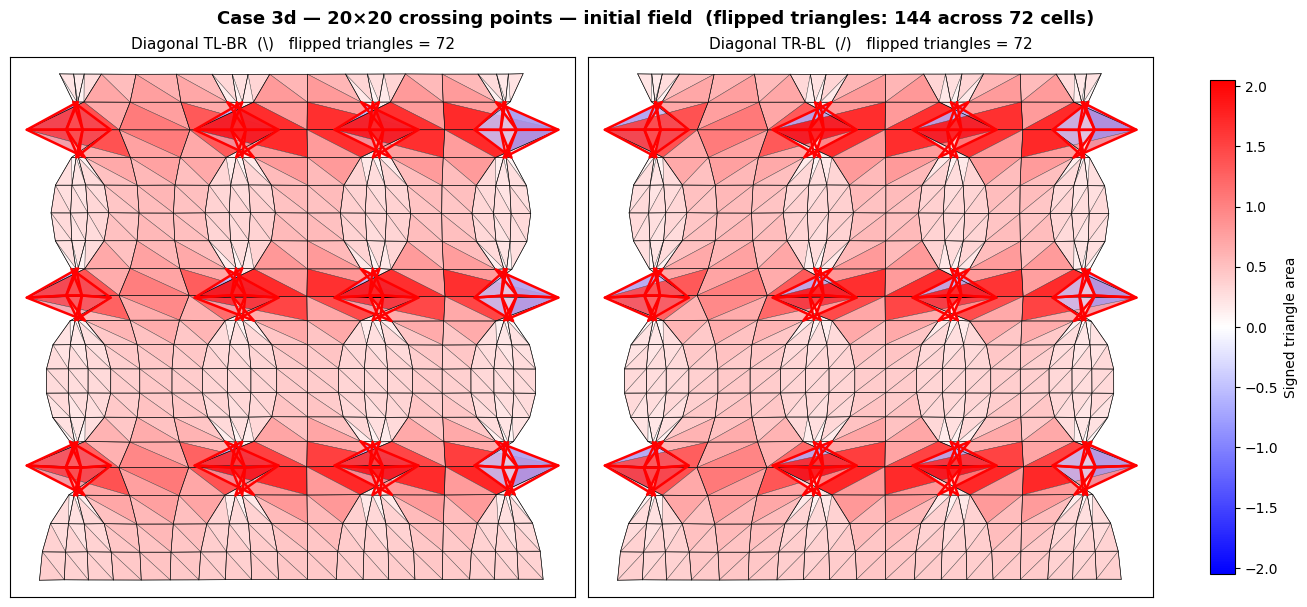

In [6]:
plot_grid_with_triangles(
    phi_init,
    title=f"{SYNTHETIC_CASES[CASE_KEY]['title']} — initial field  "
          f"(flipped triangles: {stats_init['n_flipped_total']} across "
          f"{stats_init['n_cells_flipped']} cells)")

## Optimisation against the triangle criterion

Full-grid SLSQP solve. No CD-Jdet constraint — only the 4-triangle-per-cell positivity condition.

- **Objective:** ½ · ‖u − u₀‖²  (keep the corrected field close to the input)
- **Constraint:** every triangle area ≥ τ (default τ = 0.01, the package default)
- **Boundary:** variables on the grid rim pinned to their initial values via equality bounds

Variables layout: `u = [dx.flat, dy.flat]` of length 2·H·W. Constraint vector has length 4·(H−1)·(W−1).

In [7]:
def _triangle_constraint_flat(u, H, W):
    """All 4 triangle signed areas, flattened. Length 4*(H-1)*(W-1)."""
    N = H * W
    dx = u[:N].reshape(H, W)
    dy = u[N:].reshape(H, W)
    phi = np.stack([dy, dx])
    return all_triangle_areas(phi).ravel()


def solve_triangle_slsqp(phi_init, threshold=0.01, max_iter=1000,
                         ftol=1e-8, verbose=True):
    """Full-grid SLSQP minimising L2 distance to *phi_init* subject to every
    triangle having signed area >= *threshold*. Boundary is frozen.
    """
    H, W = phi_init.shape[-2:]
    N = H * W
    dy0 = phi_init[0].ravel().copy()
    dx0 = phi_init[1].ravel().copy()
    u0 = np.concatenate([dx0, dy0])

    def objective(u):
        return 0.5 * float(np.sum((u - u0) ** 2))
    def obj_grad(u):
        return u - u0

    nlc = NonlinearConstraint(
        lambda u: _triangle_constraint_flat(u, H, W),
        threshold, np.inf,
    )

    # Freeze boundary vertices via equality bounds
    boundary_mask = np.zeros((H, W), dtype=bool)
    boundary_mask[[0, -1], :] = True
    boundary_mask[:, [0, -1]] = True
    fixed_vert = boundary_mask.ravel()
    bounds = []
    for i in range(2 * N):
        vi = i if i < N else i - N
        if fixed_vert[vi]:
            bounds.append((u0[i], u0[i]))
        else:
            bounds.append((None, None))

    t0 = time.perf_counter()
    result = minimize(
        objective, u0, jac=obj_grad, method="SLSQP",
        constraints=[nlc], bounds=bounds,
        options={"maxiter": max_iter, "ftol": ftol, "disp": verbose},
    )
    elapsed = time.perf_counter() - t0

    u_sol = result.x
    dx_sol = u_sol[:N].reshape(H, W)
    dy_sol = u_sol[N:].reshape(H, W)
    phi_sol = np.stack([dy_sol, dx_sol])
    return phi_sol, result, elapsed

In [8]:
THRESHOLD = 0.01
phi_tri, result_tri, t_tri = solve_triangle_slsqp(
    phi_init, threshold=THRESHOLD, max_iter=2000, verbose=False)

stats_tri = triangle_fold_stats(phi_tri, threshold=0.0)
jac_tri   = np.squeeze(jacobian_det2D(phi_tri))
l2_tri    = float(np.sqrt(np.sum((phi_tri - phi_init) ** 2)))

print(f"Triangle-SLSQP solve:")
print(f"  status       : {result_tri.message}")
print(f"  elapsed      : {t_tri:.3f} s")
print(f"  L2 deviation : {l2_tri:.4f}")
print(f"  min triangle : {stats_tri['min_tri_area']:+.6f}  (threshold {THRESHOLD})")
print(f"  flipped tri  : {stats_tri['n_flipped_total']}  (was {stats_init['n_flipped_total']})")
print(f"  flipped cells: {stats_tri['n_cells_flipped']}  (was {stats_init['n_cells_flipped']})")
print(f"  CD-Jdet neg  : {(jac_tri <= 0).sum()}  pixels  (was {(jac_init <= 0).sum()})")
print(f"  CD-Jdet min  : {jac_tri.min():+.6f}")

Triangle-SLSQP solve:
  status       : Optimization terminated successfully
  elapsed      : 5.314 s
  L2 deviation : 10.3231
  min triangle : +0.010000  (threshold 0.01)
  flipped tri  : 0  (was 144)
  flipped cells: 0  (was 72)
  CD-Jdet neg  : 0  pixels  (was 30)
  CD-Jdet min  : +0.020000


C:\Users\Andy\AppData\Local\Temp\ipykernel_43796\910477944.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("bwr")


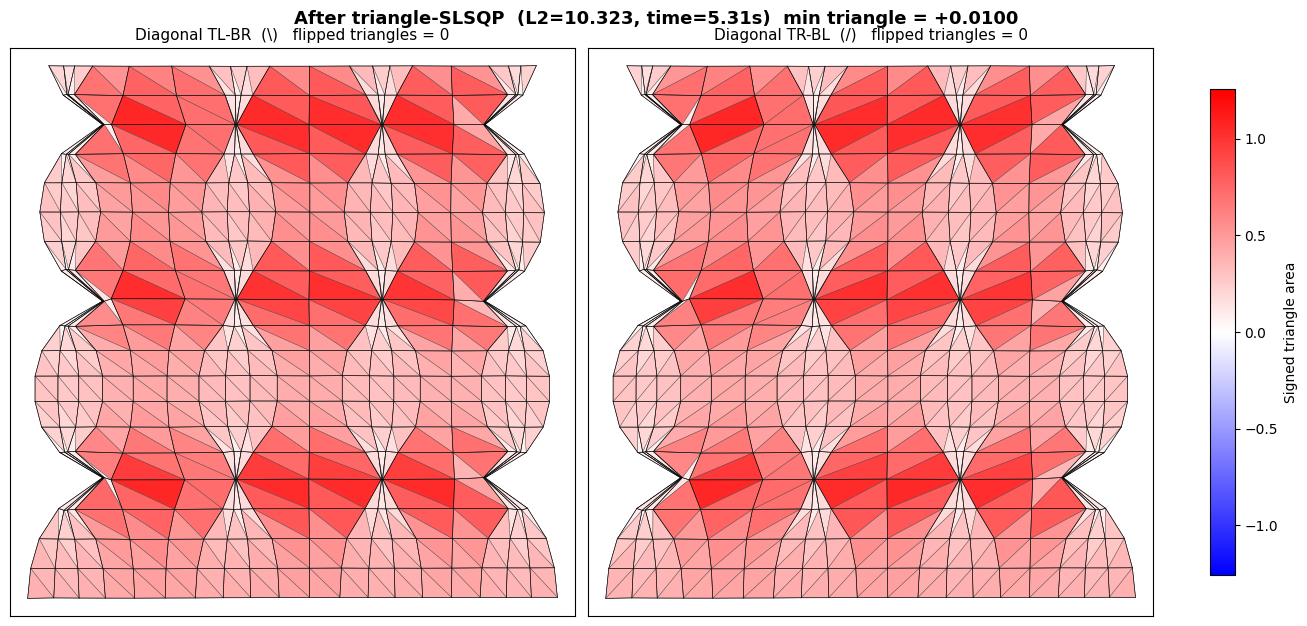

In [9]:
plot_grid_with_triangles(
    phi_tri,
    title=f"After triangle-SLSQP  (L2={l2_tri:.3f}, time={t_tri:.2f}s)  "
          f"min triangle = {stats_tri['min_tri_area']:+.4f}")

## Comparison against the CD-Jdet solver

Run the repo's standard `iterative_serial` (CD-Jdet constraint, windowed SLSQP) on the same input and re-evaluate the triangle criterion on its output. If the CD-based correction leaves triangles flipped, it means the CD constraint was satisfied locally but the PL interpolant remains non-injective under one of the diagonal triangulations.

In [10]:
t0 = time.perf_counter()
phi_cd = iterative_serial(deformation.copy(), verbose=0)
t_cd = time.perf_counter() - t0

stats_cd = triangle_fold_stats(phi_cd, threshold=0.0)
jac_cd   = np.squeeze(jacobian_det2D(phi_cd))
l2_cd    = float(np.sqrt(np.sum((phi_cd - phi_init) ** 2)))

print(f"CD-Jdet solver (iterative_serial):")
print(f"  elapsed      : {t_cd:.3f} s")
print(f"  L2 deviation : {l2_cd:.4f}")
print(f"  CD-Jdet neg  : {(jac_cd <= 0).sum()}  pixels")
print(f"  CD-Jdet min  : {jac_cd.min():+.6f}")
print(f"  flipped tri  : {stats_cd['n_flipped_total']}   "
      f"(triangle criterion evaluated post-hoc)")
print(f"  flipped cells: {stats_cd['n_cells_flipped']}")
print(f"  min triangle : {stats_cd['min_tri_area']:+.6f}")

print(f"\nSide-by-side:")
print(f"  {'metric':<22s}  {'triangle-SLSQP':>18s}  {'CD-Jdet':>18s}")
print(f"  {'time (s)':<22s}  {t_tri:>18.3f}  {t_cd:>18.3f}")
print(f"  {'L2 deviation':<22s}  {l2_tri:>18.4f}  {l2_cd:>18.4f}")
print(f"  {'flipped triangles':<22s}  {stats_tri['n_flipped_total']:>18d}  "
      f"{stats_cd['n_flipped_total']:>18d}")
print(f"  {'flipped cells':<22s}  {stats_tri['n_cells_flipped']:>18d}  "
      f"{stats_cd['n_cells_flipped']:>18d}")
print(f"  {'neg CD-Jdet px':<22s}  {(jac_tri <= 0).sum():>18d}  "
      f"{(jac_cd <= 0).sum():>18d}")

CD-Jdet solver (iterative_serial):
  elapsed      : 0.100 s
  L2 deviation : 6.1242
  CD-Jdet neg  : 0  pixels
  CD-Jdet min  : +0.010000
  flipped tri  : 163   (triangle criterion evaluated post-hoc)
  flipped cells: 82
  min triangle : -1.109683

Side-by-side:
  metric                      triangle-SLSQP             CD-Jdet
  time (s)                             5.314               0.100
  L2 deviation                       10.3231              6.1242
  flipped triangles                        0                 163
  flipped cells                            0                  82
  neg CD-Jdet px                           0                   0


C:\Users\Andy\AppData\Local\Temp\ipykernel_43796\910477944.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("bwr")


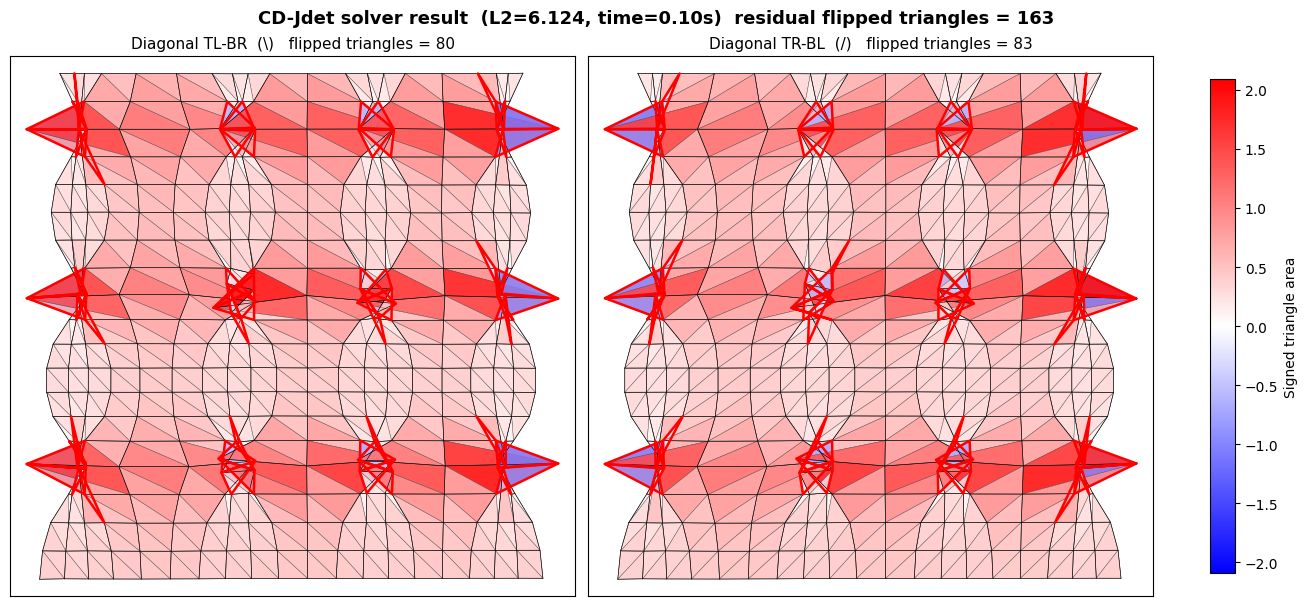

: 

In [ ]:
plot_grid_with_triangles(
    phi_cd,
    title=f"CD-Jdet solver result  (L2={l2_cd:.3f}, time={t_cd:.2f}s)  "
          f"residual flipped triangles = {stats_cd['n_flipped_total']}")